# Intro

This module takes a look at historical daily fantasy football lineups. It uses the characteristics of each lineup (such as projected fantasy points, projected ownership, etc.) to predict the probability a given lineup will reach payout in a daily fantasy contest. The resulting model can then be used to create football lineups with the goal of maximizing the chances of reaching payout.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pulp
import os
from sqlalchemy import create_engine
from pycaret.classification import *
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from dotenv import load_dotenv
from sklearn.naive_bayes import GaussianNB

In [2]:
# Set display options to show all columns
pd.set_option('display.max_columns', None)

## Data Loading & Preprocessing

There is a separate module that stores the historical data in a MySQL Workbench database. This module pulls data from that database.

**Data Sources:**
- NFL player projections (projected points, ownership, etc.)
- Contest standings (submitted lineups, final scores, resulting payouts)

In [3]:
# Creating the database engine
load_dotenv('nfl_db.env')

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [ ]:
# Load the nfl.dk_projections table into a pandas DataFrame
projections_sql = '''
SELECT 
    Player,
    Team,
    Opponent,
    DK_Position,
    DK_Salary,
    DK_Projection,
    DK_Value,
    DK_Large_Ownership,
    DK_Floor,
    DK_Ceiling,
    Slate_Info
FROM 
    nfl.dk_projections
WHERE
    Slate_Info > '2024-09-01'
'''

dk_projections = pd.read_sql(projections_sql, con=engine)
dk_projections['Player'] = dk_projections['Player'].str.title().str.strip()
dk_projections.head()

,Player,Team,Opponent,DK_Position,DK_Salary,DK_Projection,DK_Value,DK_Large_Ownership,DK_Floor,DK_Ceiling,Slate_Info
0,Tyreek Hill,MIA,JAX,WR,8700,23.0,2.7,32.6,8.5,40.3,2024-09-08
1,Justin Fields,PIT,ATL,QB,5000,17.8,2.2,7.0,9.1,28.3,2024-09-08
2,Anthony Richardson,IND,HOU,QB,6300,21.5,2.0,18.0,10.8,33.6,2024-09-08
3,Andrei Iosivas,CIN,NE,WR,3000,10.5,1.6,40.0,2.4,21.9,2024-09-08
4,Rachaad White,TB,WAS,RB,6300,17.0,1.5,28.0,6.7,30.5,2024-09-08


In [5]:
# Load the nfl.standings_with_payouts table into a pandas DataFrame
standings_sql = '''
SELECT 
    EntryName,
    Points, 
    DST, 
    FLEX, 
    QB, 
    RB1, 
    RB2, 
    TE,
    WR1,
    WR2,
    WR3,
    Slate_Info,
    Buyin,
    ROI
FROM 
    nfl.standings_with_payouts
WHERE
    Slate_Info > '2024-09-01'
'''
standings_with_payouts = pd.read_sql(standings_sql, con=engine)

# Apply title case to player columns
player_columns = ['DST', 'FLEX', 'QB', 'RB1', 'RB2', 'TE', 'WR1', 'WR2', 'WR3']
standings_with_payouts[player_columns] = standings_with_payouts[player_columns].apply(lambda x: x.str.title().str.strip())

standings_with_payouts.head()

,EntryName,Points,DST,FLEX,QB,RB1,RB2,TE,WR1,WR2,WR3,Slate_Info,Buyin,ROI
0,BeRich11 (42/150),189.36,Bears,Terry Mclaurin,Jayden Daniels,Joe Mixon,J.K. Dobbins,Kyle Pitts,Tyreek Hill,Chris Godwin,Ladd Mcconkey,2024-09-08,0.5,19999.0
1,bmglass100 (104/150),188.98,Bears,Mike Evans,Anthony Richardson,Alvin Kamara,Kenneth Walker Iii,Brock Bowers,Tyreek Hill,Alec Pierce,Andrei Iosivas,2024-09-08,0.5,9999.0
2,wwilder73 (111/150),187.18,Cowboys,Rachaad White,Anthony Richardson,Joe Mixon,Rhamondre Stevenson,Hayden Hurst,Mike Evans,Jaylen Waddle,Alec Pierce,2024-09-08,0.5,7999.0
3,Stubbs0001 (44/150),186.86,Bears,Mike Evans,Baker Mayfield,Kenneth Walker Iii,Jerome Ford,Kyle Pitts,Nico Collins,Chris Godwin,Brian Thomas Jr.,2024-09-08,0.5,5999.0
4,Balldrick (61/150),186.66,Cowboys,Jalen Mcmillan,Baker Mayfield,Joe Mixon,Brian Robinson Jr.,Kyle Pitts,Tyreek Hill,Jaylen Waddle,Chris Godwin,2024-09-08,0.5,3999.0


**Merging Dataframes**

The standings_with_payouts dataframe shows the names of the players within each lineup. The projections of each player need to be brought in from the player projections dataframe by merging dataframes. This merge needs to be done on both the player name and the date of the contest (Slate_Info). This is a bit tricky because a merge needs to be done across 9 columns. This is completed below.

In [6]:
# Define the player columns to merge on
player_columns = ['DST', 'FLEX', 'QB', 'RB1', 'RB2', 'TE', 'WR1', 'WR2', 'WR3']

# Loop through each player column and perform the left joins
merged_df = standings_with_payouts.copy()

for player in player_columns:
    merged_df = pd.merge(
        merged_df,
        dk_projections,
        left_on=[player, 'Slate_Info'],
        right_on=['Player', 'Slate_Info'],
        how='left',
        suffixes=('', f'_{player}')
    ).drop(columns=['Player'])

merged_df.head(2)

,EntryName,Points,DST,FLEX,QB,RB1,RB2,TE,WR1,WR2,WR3,Slate_Info,Buyin,ROI,Team,Opponent,DK_Position,DK_Salary,DK_Projection,DK_Value,DK_Large_Ownership,DK_Floor,DK_Ceiling,Team_FLEX,Opponent_FLEX,DK_Position_FLEX,DK_Salary_FLEX,DK_Projection_FLEX,DK_Value_FLEX,DK_Large_Ownership_FLEX,DK_Floor_FLEX,DK_Ceiling_FLEX,Team_QB,Opponent_QB,DK_Position_QB,DK_Salary_QB,DK_Projection_QB,DK_Value_QB,DK_Large_Ownership_QB,DK_Floor_QB,DK_Ceiling_QB,Team_RB1,Opponent_RB1,DK_Position_RB1,DK_Salary_RB1,DK_Projection_RB1,DK_Value_RB1,DK_Large_Ownership_RB1,DK_Floor_RB1,DK_Ceiling_RB1,Team_RB2,Opponent_RB2,DK_Position_RB2,DK_Salary_RB2,DK_Projection_RB2,DK_Value_RB2,DK_Large_Ownership_RB2,DK_Floor_RB2,DK_Ceiling_RB2,Team_TE,Opponent_TE,DK_Position_TE,DK_Salary_TE,DK_Projection_TE,DK_Value_TE,DK_Large_Ownership_TE,DK_Floor_TE,DK_Ceiling_TE,Team_WR1,Opponent_WR1,DK_Position_WR1,DK_Salary_WR1,DK_Projection_WR1,DK_Value_WR1,DK_Large_Ownership_WR1,DK_Floor_WR1,DK_Ceiling_WR1,Team_WR2,Opponent_WR2,DK_Position_WR2,DK_Salary_WR2,DK_Projection_WR2,DK_Value_WR2,DK_Large_Ownership_WR2,DK_Floor_WR2,DK_Ceiling_WR2,Team_WR3,Opponent_WR3,DK_Position_WR3,DK_Salary_WR3,DK_Projection_WR3,DK_Value_WR3,DK_Large_Ownership_WR3,DK_Floor_WR3,DK_Ceiling_WR3
0,BeRich11 (42/150),189.36,Bears,Terry Mclaurin,Jayden Daniels,Joe Mixon,J.K. Dobbins,Kyle Pitts,Tyreek Hill,Chris Godwin,Ladd Mcconkey,2024-09-08,0.5,19999.0,CHI,TEN,DST,3400.0,8.2,0.5,5.3,2.0,15.7,WAS,TB,WR,5600.0,12.8,-1.3,10.4,3.5,25.5,WAS,TB,QB,5700.0,19.0,1.3,9.0,9.8,29.5,HOU,IND,RB,6600.0,15.6,-0.4,8.4,5.8,28.6,LAC,LV,RB,4900.0,10.9,-1.8,3.2,3.5,21.5,ATL,PIT,TE,4600.0,11.5,-0.6,25.5,2.8,22.8,MIA,JAX,WR,8700.0,23.0,2.7,32.6,8.5,40.3,TB,WAS,WR,5800.0,14.9,0.4,16.2,4.9,29.0,LAC,LV,WR,4700.0,9.6,-2.7,8.6,2.1,20.0
1,bmglass100 (104/150),188.98,Bears,Mike Evans,Anthony Richardson,Alvin Kamara,Kenneth Walker Iii,Brock Bowers,Tyreek Hill,Alec Pierce,Andrei Iosivas,2024-09-08,0.5,9999.0,CHI,TEN,DST,3400.0,8.2,0.5,5.3,2.0,15.7,TB,WAS,WR,7300.0,15.5,-1.9,7.8,4.6,29.9,IND,HOU,QB,6300.0,21.5,2.0,18.0,10.8,33.6,NO,CAR,RB,6700.0,17.0,0.8,22.9,6.9,30.3,SEA,DEN,RB,6100.0,15.2,0.1,21.3,5.6,28.3,LV,LAC,TE,4500.0,8.5,-3.4,2.0,1.9,17.5,MIA,JAX,WR,8700.0,23.0,2.7,32.6,8.5,40.3,IND,HOU,WR,4000.0,7.0,-4.0,0.3,0.8,15.9,CIN,NE,WR,3000.0,10.5,1.6,40.0,2.4,21.9


In [7]:
# Calculate the number of games for each 'Slate_Info' and merge into master dataframe

# List of team columns
team_columns = ['Team', 'Team_FLEX', 'Team_QB', 'Team_RB1', 'Team_RB2', 'Team_TE', 'Team_WR1', 'Team_WR2', 'Team_WR3']

# Initialize an empty list to store results for each 'Slate_Info'
results = []

# Iterate over each unique 'Slate_Info'
for slate in merged_df['Slate_Info'].unique():
    # Filter the DataFrame for the current 'Slate_Info'
    slate_df = merged_df[merged_df['Slate_Info'] == slate]
    
    # Concatenate all team columns, drop nulls, and get unique teams
    unique_teams = pd.concat([slate_df[col].dropna() for col in team_columns]).unique()
    
    # Calculate the count of unique teams divided by 2 and convert to integer
    slate_count = int(len(unique_teams) / 2)
    
    # Store the result in a dictionary
    results.append({'Slate_Info': slate, 'Slate_Count': slate_count})

# Create a DataFrame from results and merge with original 'merged_df'
slate_count_df = pd.DataFrame(results)
merged_df = merged_df.merge(slate_count_df, on='Slate_Info')

slate_count_df.head()

,Slate_Info,Slate_Count
0,2024-09-08,12
1,2024-09-15,13
2,2024-09-22,12
3,2024-09-29,12
4,2024-10-06,10


In [8]:
# Electing to only use full slates here (Sunday games)
merged_df = merged_df[merged_df['Slate_Count'] >= 8]

In [9]:
player_1_columns_to_rename = {
    'Team': 'Team_DST',
    'Opponent': 'Opponent_DST',
    'DK_Position': 'DK_Position_DST',
    'DK_Salary': 'DK_Salary_DST',
    'DK_Projection': 'DK_Projection_DST',
    'DK_Value': 'DK_Value_DST',
    'DK_Large_Ownership': 'DK_Large_Ownership_DST',
    'DK_Floor': 'DK_Floor_DST',
    'DK_Ceiling': 'DK_Ceiling_DST',
}
merged_df.rename(columns=player_1_columns_to_rename, inplace=True)

## Feature Engineering

Feature engineering is being completed before exploratory data analysis in this case. There is a lot of domain knowledge on this topic and there is already a strong idea on which features will be useful.

Also, the raw data is not very meaningful without transformation. The goal of this model is to predict how lineups may perform on unforseen slates. However, not all slates are on the same scale. The simplest way to describe this is to look at the total projected fantasy points of lineups. On a low scoring slate, a good lineup may be projected to score 120 fantasy points. This may happen when there are few games on the slate to choose from. On a high scoring slate, a good lineup may be projected to score 145 fantasy points. So simply saying a lineup is projected to score x is almost meaningless.

Each slate needs to be set to the same scale to account for this. This is done by converting the features to a percentile of the maximum projected possible for each slate. This acts similar to how a MinMaxScaler works. At this point in the module, the projected maximum projections possible for a lineup for each slate are not known. However, they can be quickly solved for by using linear programming optimization.

**Calculating the historical maxes to help calculate percentiles later**

The cell below uses linear programming optimization to solve for the maximum possible values for a given feature for each slate. The solver runs with the following constraints:
- Salary must be below 50000
- Must use 9 players
- Must have one QB
- Must have one DST
- Must have at least 2 RB
- Must have at least 3 WR
- Must have at least 1 TE

In [10]:
# Initialize an empty DataFrame to store results
maxes_possible_by_slate_df = pd.DataFrame(columns=['Slate_Info', 
                                                   'Max_Poss_Total_Proj_Pts', 
                                                   'Max_Poss_Total_Own', 
                                                   'Max_Poss_Total_Floor', 
                                                   'Max_Poss_Total_Ceiling', 
                                                   'Max_Poss_Total_Value'])

# Define a function to solve the optimization problem for a specific column using the working solver setup
def solve_for_column(column_name, player_list):
    # Define player IDs and corresponding LpVariables
    player_ids = player_list.index
    player_vars = pulp.LpVariable.dicts('player', player_ids, cat='Binary')

    # Define problem
    prob = pulp.LpProblem("DK_NFL", pulp.LpMaximize)

    # Objective: Maximize the specified column
    prob += pulp.lpSum([player_list[column_name][i] * player_vars[i] for i in player_ids])

    # Total Salary constraint
    prob += pulp.lpSum([player_list['DK_Salary'][i] * player_vars[i] for i in player_ids]) <= 50000

    # Total player count constraint
    prob += pulp.lpSum([player_vars[i] for i in player_ids]) == 9

    # Position constraints based on 'DK_Position' column
    prob += pulp.lpSum([player_vars[i] for i in player_ids if player_list['DK_Position'][i] == 'QB']) == 1
    prob += pulp.lpSum([player_vars[i] for i in player_ids if player_list['DK_Position'][i] == 'DST']) == 1
    prob += pulp.lpSum([player_vars[i] for i in player_ids if player_list['DK_Position'][i] == 'RB']) >= 2
    prob += pulp.lpSum([player_vars[i] for i in player_ids if player_list['DK_Position'][i] == 'WR']) >= 3
    prob += pulp.lpSum([player_vars[i] for i in player_ids if player_list['DK_Position'][i] == 'TE']) >= 1

    # Solve the problem
    optimization_result = prob.solve()

    # Extract the optimized value for the column, checking for feasibility
    if optimization_result == pulp.LpStatusOptimal:
        optimized_value = pulp.value(prob.objective)
    else:
        optimized_value = 0  # Assign zero if no feasible solution was found
    
    return optimized_value


# Process each unique 'Slate_Info' and apply the function
def process_slate_info(dataframe):
    global maxes_possible_by_slate_df
    # Get unique Slate_Info dates
    unique_dates = dataframe['Slate_Info'].unique()

    # Loop through each unique Slate_Info date
    for slate_date in unique_dates:
        # Filter the DataFrame for the current slate date
        player_list = dataframe[dataframe['Slate_Info'] == slate_date]
        
        # Apply the optimization function for each column
        results_row = pd.DataFrame({
            'Slate_Info': [slate_date],  # Slate date
            'Max_Poss_Total_Proj_Pts': [solve_for_column('DK_Projection', player_list)],
            'Max_Poss_Total_Own': [solve_for_column('DK_Large_Ownership', player_list)],
            'Max_Poss_Total_Floor': [solve_for_column('DK_Floor', player_list)],
            'Max_Poss_Total_Ceiling': [solve_for_column('DK_Ceiling', player_list)],
            'Max_Poss_Total_Value': [solve_for_column('DK_Value', player_list)],
        })

        # Append the row to the main DataFrame
        maxes_possible_by_slate_df = pd.concat([maxes_possible_by_slate_df, results_row], ignore_index=True)


process_slate_info(dk_projections)

maxes_possible_by_slate_df

,Slate_Info,Max_Poss_Total_Proj_Pts,Max_Poss_Total_Own,Max_Poss_Total_Floor,Max_Poss_Total_Ceiling,Max_Poss_Total_Value
0,2024-09-08,138.2,217.6,50.9,252.9,10.8
1,2024-09-15,150.0,224.9,59.5,266.7,22.2
2,2024-09-22,148.6,222.3,59.7,262.0,20.7
3,2024-09-29,141.3,198.4,55.9,252.2,13.5
4,2024-10-06,140.9,227.3,52.9,257.3,13.4
5,2024-10-13,139.7,221.6,53.3,251.8,12.8
6,2024-10-20,140.6,219.6,55.9,250.3,13.5
7,2024-10-27,141.4,214.8,53.9,253.5,13.9
8,2024-11-03,145.5,210.1,55.4,262.7,18.3
9,2024-11-10,140.5,235.4,56.0,252.4,13.9


In [11]:
# Merging the the max possible values into the main dataframe
merged_df = pd.merge(merged_df, maxes_possible_by_slate_df, how='left', on='Slate_Info')

In [12]:
def count_positional_stack(df):
    """
    Counts players on the same team as the QB for each position group for a lineup.

    This concept is known as a 'stack' in daily fantasy.

    Lineups with more correlation tend to have higher risk and higher reward.

    For example, if Tom Brady throws a touchdown to Rob Gronkowski, and both players are in that lineup, 
        that is scoring two TDs with one play.
    """

    rb_columns = ['Team_RB1', 'Team_RB2']
    wr_te_columns = ['Team_WR1', 'Team_WR2', 'Team_WR3', 'Team_TE']
    
    # Calculate the matches for each position group
    df['RB_Stack_Count'] = np.sum((df[rb_columns].values == df['Team_QB'].values[:, None]), axis=1)
    df['WR_TE_Stack_Count'] = np.sum((df[wr_te_columns].values == df['Team_QB'].values[:, None]), axis=1)
    
    # Add FLEX to the stack counts based on DK_Position_FLEX
    df['FLEX_Stack_Count'] = (df['Team_FLEX'] == df['Team_QB']).astype(int)
    
    # Increment the appropriate positional stack count based on DK_Position_FLEX
    df['RB_Stack_Count'] += df['FLEX_Stack_Count'] * (df['DK_Position_FLEX'] == 'RB')
    df['WR_TE_Stack_Count'] += df['FLEX_Stack_Count'] * (df['DK_Position_FLEX'].isin(['WR', 'TE']))
    
    # Drop the intermediate FLEX_Stack_Count column
    df.drop(columns=['FLEX_Stack_Count'], inplace=True)
    
    return df


merged_df = count_positional_stack(merged_df)

In [13]:
# Create dummy variables for 'DK_Position_FLEX' and concatenate them to the DataFrame
# There are fantasy football podcasts that suggest that the FLEX position should be a WR. It will be good to explore this in the model.
merged_df = pd.concat([merged_df, pd.get_dummies(merged_df['DK_Position_FLEX'], prefix='FLEX')], axis=1)

In [14]:
# Summing individual player stats for lineup totals
merged_df['Total_Salary'] = merged_df.filter(like='DK_Salary').sum(axis=1)
merged_df['Total_Proj_Pts'] = merged_df.filter(like='DK_Projection').sum(axis=1)
merged_df['Total_Own'] = merged_df.filter(like='DK_Large_Ownership').sum(axis=1)
merged_df['Total_Floor'] = merged_df.filter(like='DK_Floor').sum(axis=1)
merged_df['Total_Ceiling'] = merged_df.filter(like='DK_Ceiling').sum(axis=1)
merged_df['Total_Value'] = merged_df.filter(like='DK_Value').sum(axis=1)

# Calculating min and max for projected points and ownership
merged_df['Min_Proj_Pts'] = merged_df.filter(like='DK_Projection').min(axis=1)
merged_df['Max_Proj_Pts'] = merged_df.filter(like='DK_Projection').max(axis=1)
merged_df['Min_Own'] = merged_df.filter(like='DK_Large_Ownership').min(axis=1)
merged_df['Max_Own'] = merged_df.filter(like='DK_Large_Ownership').max(axis=1)

# New exploratory features
# Range Ownership
merged_df['Range_Ownership'] = merged_df['Max_Own'] - merged_df['Min_Own']

# High projection count (count of players with DK_Projection > 10)
threshold = merged_df['Max_Poss_Total_Proj_Pts'] / 10
merged_df['High_Projection_Count'] = (merged_df.filter(like='DK_Projection') > threshold.values[:, None]).sum(axis=1)

# Variance of DK Projections and Ownership
merged_df['Variance_DK_Projection'] = merged_df.filter(like='DK_Projection').var(axis=1)
merged_df['Variance_Ownership'] = merged_df.filter(like='DK_Large_Ownership').var(axis=1)
merged_df['Variance_Salary'] = merged_df.filter(like='DK_Salary').var(axis=1)

# Percent of max possible by slate
merged_df['Pct_Max_Total_Proj_Pts'] = merged_df['Total_Proj_Pts'] / merged_df['Max_Poss_Total_Proj_Pts']
merged_df['Pct_Max_Total_Own'] = merged_df['Total_Own'] / merged_df['Max_Poss_Total_Own']
merged_df['Pct_Max_Total_Floor'] = merged_df['Total_Floor'] / merged_df['Max_Poss_Total_Floor']
merged_df['Pct_Max_Total_Ceiling'] = merged_df['Total_Ceiling'] / merged_df['Max_Poss_Total_Ceiling']
merged_df['Pct_Max_Total_Value'] = merged_df['Total_Value'] / merged_df['Max_Poss_Total_Value']

# Individual stats by slate
merged_df['Pct_Min_Proj_Pts'] = (merged_df['Min_Proj_Pts'] / merged_df.groupby('Slate_Info')['Max_Proj_Pts'].transform('max'))
merged_df['Pct_Max_Proj_Pts'] = (merged_df['Max_Proj_Pts'] / merged_df.groupby('Slate_Info')['Max_Proj_Pts'].transform('max'))
merged_df['Pct_Min_Own'] = (merged_df['Min_Own'] / merged_df.groupby('Slate_Info')['Max_Own'].transform('max'))
merged_df['Pct_Max_Own'] = (merged_df['Max_Own'] / merged_df.groupby('Slate_Info')['Max_Own'].transform('max'))
 
# Binary made payout column
merged_df['Made_Payout'] = merged_df['ROI'].apply(lambda x: 1 if x >= 0 else 0)

cleaned_df = merged_df[['Pct_Min_Proj_Pts', 'Pct_Max_Proj_Pts', 'Pct_Min_Own', 'Pct_Max_Own',
           'Pct_Max_Total_Proj_Pts', 'Pct_Max_Total_Own', 'Pct_Max_Total_Ceiling', 'Pct_Max_Total_Value',
           'Total_Salary', 'High_Projection_Count', 'Variance_DK_Projection', 'Variance_Ownership', 'Variance_Salary',
           'RB_Stack_Count', 'WR_TE_Stack_Count', 'FLEX_RB', 'FLEX_WR', 'FLEX_TE', 'Slate_Info', 'Slate_Count', 'Made_Payout', 'ROI']]

In [15]:
cleaned_df.head()

,Pct_Min_Proj_Pts,Pct_Max_Proj_Pts,Pct_Min_Own,Pct_Max_Own,Pct_Max_Total_Proj_Pts,Pct_Max_Total_Own,Pct_Max_Total_Ceiling,Pct_Max_Total_Value,Total_Salary,High_Projection_Count,Variance_DK_Projection,Variance_Ownership,Variance_Salary,RB_Stack_Count,WR_TE_Stack_Count,FLEX_RB,FLEX_WR,FLEX_TE,Slate_Info,Slate_Count,Made_Payout,ROI
0,0.356522,1.000000,0.0800,0.8150,0.908104,0.547794,0.920917,-0.175926,50000.0,4,22.455278,96.090278,2.222778e+06,0,1,False,True,False,2024-09-08,12,1,19999.0
1,0.304348,1.000000,0.0075,1.0000,0.914616,0.690257,0.922894,-0.148148,50000.0,5,34.382778,193.901111,3.725278e+06,0,1,False,True,False,2024-09-08,12,1,9999.0
2,0.265217,0.934783,0.0075,0.7000,0.860347,0.425551,0.876631,-0.768519,49600.0,5,27.948611,86.653611,2.198611e+06,0,1,True,False,False,2024-09-08,12,1,7999.0
3,0.356522,0.795652,0.1325,0.6375,0.894356,0.489430,0.919731,-0.333333,50000.0,5,9.842500,54.305000,1.472778e+06,0,2,False,True,False,2024-09-08,12,1,5999.0
4,0.291304,1.000000,0.0150,0.8150,0.884949,0.505515,0.904705,-0.472222,50000.0,5,28.171111,133.821944,2.557778e+06,0,2,False,True,False,2024-09-08,12,1,3999.0


## EDA

In [16]:
cleaned_df.groupby('Slate_Info').mean()

,Pct_Min_Proj_Pts,Pct_Max_Proj_Pts,Pct_Min_Own,Pct_Max_Own,Pct_Max_Total_Proj_Pts,Pct_Max_Total_Own,Pct_Max_Total_Ceiling,Pct_Max_Total_Value,Total_Salary,High_Projection_Count,Variance_DK_Projection,Variance_Ownership,Variance_Salary,RB_Stack_Count,WR_TE_Stack_Count,FLEX_RB,FLEX_WR,FLEX_TE,Slate_Count,Made_Payout,ROI
Slate_Info,,,,,,,,,,,,,,,,,,,,,
2024-09-08,0.284916,0.906592,0.047913,0.735528,0.883909,0.499439,0.898982,-0.481800,49719.245791,4.416796,22.427750,93.109778,2.759771e+06,0.163080,1.197564,0.236530,0.679602,0.079337,12.0,0.221227,-0.159000
2024-09-15,0.276444,0.916475,0.043776,0.831272,0.878358,0.543281,0.896714,0.199771,49721.658116,4.542815,31.443476,133.582583,3.042962e+06,0.158337,1.174380,0.448442,0.458086,0.090798,13.0,0.221133,-0.158999
2024-09-22,0.284700,0.930842,0.060635,0.885822,0.887711,0.602437,0.904445,0.203263,49871.177460,4.601009,27.682718,136.465629,2.611222e+06,0.198150,1.265433,0.612532,0.332885,0.053659,12.0,0.260050,-0.158955
2024-09-29,0.306929,0.939859,0.068138,0.772720,0.893779,0.565512,0.907298,-0.111054,49841.621112,4.895632,24.961664,65.162240,2.705807e+06,0.241317,1.205557,0.478176,0.415606,0.105562,12.0,0.209661,-0.159008
2024-10-06,0.308882,0.902164,0.085539,0.891135,0.891458,0.591878,0.899317,-0.165362,49845.937763,4.505299,22.318194,89.070603,2.599973e+06,0.160050,1.237006,0.413877,0.538352,0.046257,10.0,0.209672,-0.158966
2024-10-13,0.257174,0.830253,0.058231,0.816159,0.871845,0.505319,0.893994,-0.464499,49801.519484,4.602579,24.329774,84.407043,2.666398e+06,0.171461,1.064816,0.429380,0.438071,0.130137,10.0,0.259826,-0.158958
2024-10-20,0.229864,0.811493,0.071322,0.856215,0.873295,0.508706,0.900199,-0.360008,49840.912795,4.522684,28.494926,73.092666,3.125597e+06,0.153310,1.238703,0.195690,0.530110,0.272752,10.0,0.276465,-0.093821
2024-10-27,0.310121,0.880551,0.062237,0.867916,0.890370,0.533963,0.908473,-0.130610,49820.075694,4.829268,23.092742,87.961527,3.029576e+06,0.189235,1.181161,0.429184,0.368124,0.200925,13.0,0.256686,-0.158372
2024-11-03,0.255401,0.882151,0.049802,0.828796,0.859339,0.473307,0.874172,-0.148117,49791.107373,4.178581,28.427962,74.493802,3.175240e+06,0.182955,0.908158,0.402019,0.365181,0.229156,12.0,0.259938,-0.158957


In [17]:
cleaned_df.isnull().sum()

Pct_Min_Proj_Pts          1219
Pct_Max_Proj_Pts          1219
Pct_Min_Own               1219
Pct_Max_Own               1219
Pct_Max_Total_Proj_Pts       0
Pct_Max_Total_Own            0
Pct_Max_Total_Ceiling        0
Pct_Max_Total_Value          0
Total_Salary                 0
High_Projection_Count        0
Variance_DK_Projection    1223
Variance_Ownership        1223
Variance_Salary           1223
RB_Stack_Count               0
WR_TE_Stack_Count            0
FLEX_RB                      0
FLEX_WR                      0
FLEX_TE                      0
Slate_Info                   0
Slate_Count                  0
Made_Payout                  0
ROI                          0
dtype: int64

In [18]:
# Calculate the average Made_Payout for each Slate_Info
# ROI should be the same as the rake for the slate
average_slate_payouts = cleaned_df.groupby('Slate_Info')[['Made_Payout', 'ROI']].mean().reset_index()
average_slate_payouts

,Slate_Info,Made_Payout,ROI
0,2024-09-08,0.221227,-0.159000
1,2024-09-15,0.221133,-0.158999
2,2024-09-22,0.260050,-0.158955
3,2024-09-29,0.209661,-0.159008
4,2024-10-06,0.209672,-0.158966
5,2024-10-13,0.259826,-0.158958
6,2024-10-20,0.276465,-0.093821
7,2024-10-27,0.256686,-0.158372
8,2024-11-03,0.259938,-0.158957
9,2024-11-10,0.269638,-0.158958


In [19]:
average_slate_made_payout = average_slate_payouts['Made_Payout'].mean()
average_slate_made_payout

0.2507555166591367

In [20]:
average_slate_roi = average_slate_payouts['ROI'].mean()
average_slate_roi

-0.15509188045568123

In [21]:
# Cases where a player in a lineup did not have a projection
cleaned_df = cleaned_df.dropna()

In [22]:
# Get rid of blank/junk lineups
cleaned_df = cleaned_df[cleaned_df['Pct_Max_Total_Proj_Pts'] > 0.7]

# Lineups with reasonable pricing
cleaned_df = cleaned_df[cleaned_df['Total_Salary'] > 48500]

# Get rid of lineups with any player projected for 0
if 'Pct_Min_Proj_Pts' in cleaned_df.columns:
    cleaned_df = cleaned_df[cleaned_df['Pct_Min_Proj_Pts'] > 0]

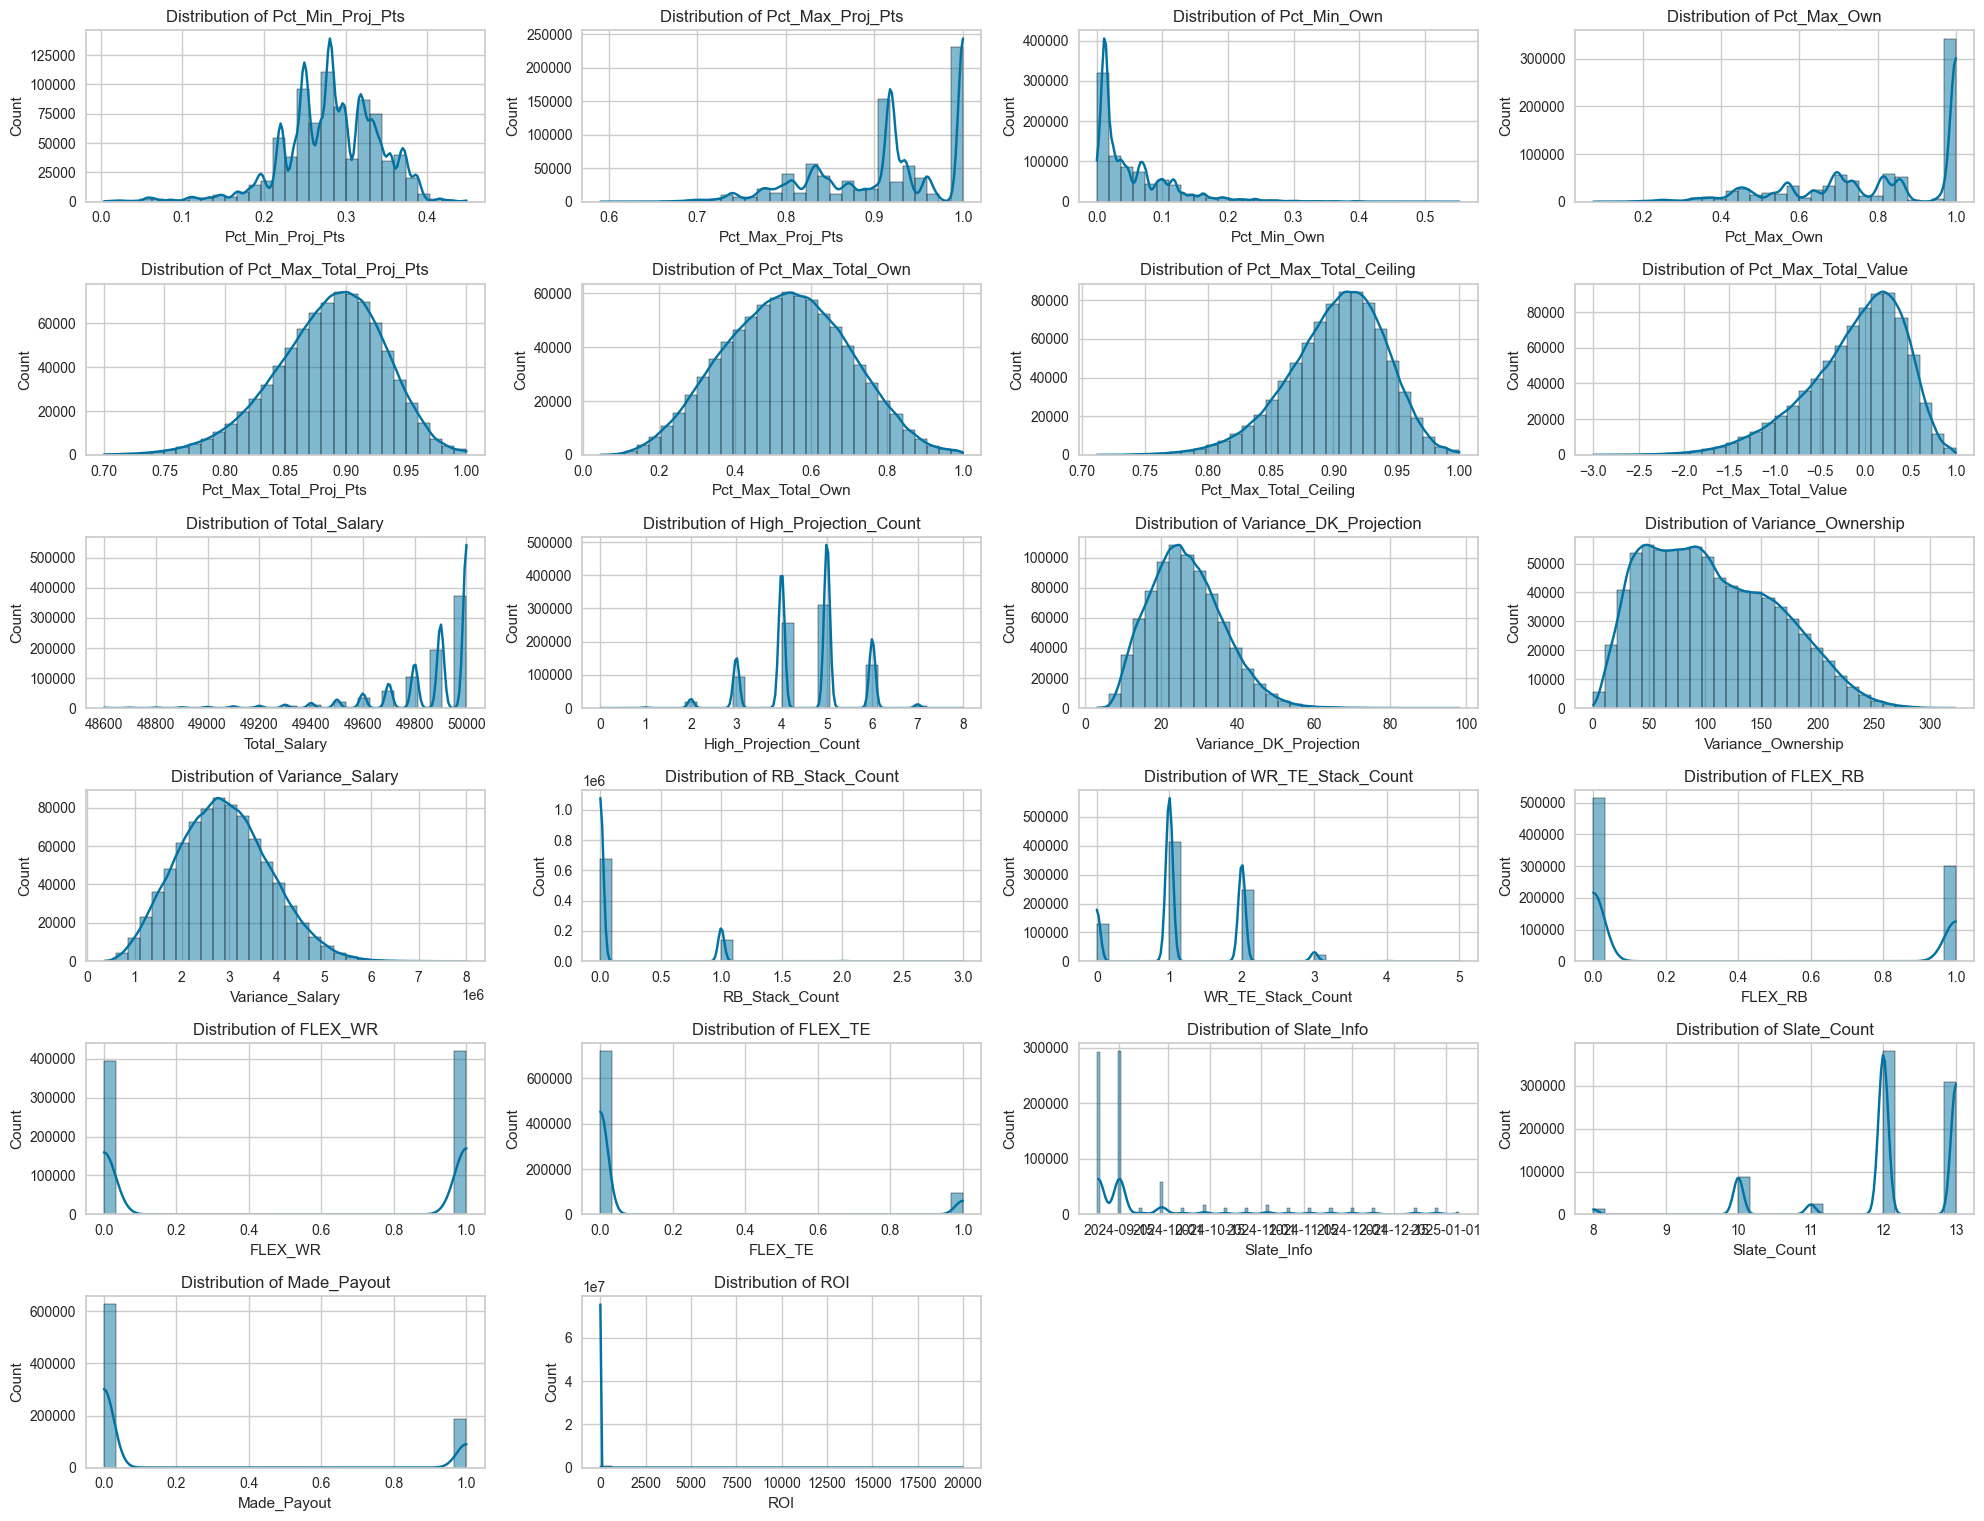

In [23]:
# Set up the plot grid for visualizing the distribution of each feature
plt.figure(figsize=(20, 20))
for i, column in enumerate(cleaned_df.columns, 1):
    plt.subplot(8, 4, i)
    sns.histplot(cleaned_df[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()

# Show the distribution plots
plt.show()

### Data Preprocessing

**Balancing Datasets**

The large majority of lineups do not reach payout. For a more balanced dataset for model building, the target variable is going to use undersampling for each slate. All non-duplicate lineups that reach payout will be available for modeling. Only a sampled portion of lineups that missed payout will be available for modeling. There will be an equal number of lineups that miss and make payout for each slate in the training dataset.

In [24]:
# Remove duplicates
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

In [25]:
# Group by 'Slate_Info' and find the minimum count of 'Made_Payout' in each group
min_counts = cleaned_df.groupby('Slate_Info')['Made_Payout'].value_counts().groupby(level=0).min()

# Now sample the minimum count for both 'Made_Payout' options within each 'Slate_Info'
balanced_df = pd.DataFrame()  # Initialize an empty DataFrame to store the balanced data

for slate_info, min_count in min_counts.items():
    # Filter the data for the current 'Slate_Info'
    slate_df = cleaned_df[cleaned_df['Slate_Info'] == slate_info]
    
    # Sample the same number of 0's and 1's for 'Made_Payout'
    payout_0 = slate_df[slate_df['Made_Payout'] == 0].sample(min_count, random_state=42)
    payout_1 = slate_df[slate_df['Made_Payout'] == 1].sample(min_count, random_state=42)
    
    # Append the balanced samples to the balanced_df
    balanced_df = pd.concat([balanced_df, payout_0, payout_1])

# Reset the index of the balanced dataframe
balanced_df = balanced_df.reset_index(drop=True)

# Now you have a balanced dataset ready for model building
balanced_df.head()

,Pct_Min_Proj_Pts,Pct_Max_Proj_Pts,Pct_Min_Own,Pct_Max_Own,Pct_Max_Total_Proj_Pts,Pct_Max_Total_Own,Pct_Max_Total_Ceiling,Pct_Max_Total_Value,Total_Salary,High_Projection_Count,Variance_DK_Projection,Variance_Ownership,Variance_Salary,RB_Stack_Count,WR_TE_Stack_Count,FLEX_RB,FLEX_WR,FLEX_TE,Slate_Info,Slate_Count,Made_Payout,ROI
0,0.265217,1.000000,0.0825,0.8150,0.911722,0.567096,0.917359,-0.138889,50000.0,5,32.555000,108.053611,4.422778e+06,1,0,True,False,False,2024-09-08,12,0,-1.0
1,0.269565,0.934783,0.0675,0.6375,0.899421,0.572151,0.920917,-0.351852,50000.0,6,20.781111,75.607500,2.127778e+06,0,2,False,True,False,2024-09-08,12,0,-1.0
2,0.260870,0.834783,0.0400,0.6375,0.869754,0.450827,0.893634,-0.731481,50000.0,4,14.547778,81.112500,1.722778e+06,1,1,False,False,True,2024-09-08,12,0,-1.0
3,0.278261,0.804348,0.0400,1.0000,0.866860,0.432904,0.882167,-0.638889,49500.0,4,15.913611,143.252500,3.372500e+06,1,1,False,True,False,2024-09-08,12,0,-1.0
4,0.282609,0.804348,0.0675,1.0000,0.915340,0.632812,0.919336,-0.009259,50000.0,6,18.975278,166.092500,3.462778e+06,0,1,True,False,False,2024-09-08,12,0,-1.0


In [26]:
balanced_df.groupby('Slate_Info').size()

Slate_Info
2024-09-08    118902
2024-09-15    123036
2024-09-22      5936
2024-09-29     23782
2024-10-06      4864
2024-10-13      8970
2024-10-20      5906
2024-10-27      5716
2024-11-03      8510
2024-11-10      6166
2024-11-17      5952
2024-11-24      5926
2024-12-01      5902
2024-12-08      5666
2024-12-22      6004
2024-12-29      5704
2025-01-05      2204
dtype: int64

In [27]:
balanced_df.groupby('Slate_Info')['ROI'].mean()

Slate_Info
2024-09-08    0.947183
2024-09-15    0.944977
2024-09-22    0.646314
2024-09-29    0.983641
2024-10-06    1.025265
2024-10-13    0.634581
2024-10-20    0.636996
2024-10-27    0.680980
2024-11-03    0.638778
2024-11-10    0.572282
2024-11-17    0.618725
2024-11-24    0.642614
2024-12-01    0.646179
2024-12-08    0.663742
2024-12-22    0.608553
2024-12-29    0.619085
2025-01-05    0.455231
Name: ROI, dtype: float64

In [28]:
balanced_df_mean_roi = balanced_df.groupby('Slate_Info')['ROI'].mean().mean()
balanced_df_mean_roi

0.7038309012659654

**Drop Correlated Features**

In [29]:
# Exclude 'Slate_Info' from the dataframe
df_for_correlation = balanced_df.drop(columns=['Slate_Info'])

# Calculate the correlation matrix
correlation_matrix = df_for_correlation.corr().abs()

# Set the correlation threshold (e.g., 0.9)
correlation_threshold = 0.8

# Identify pairs of highly correlated features
highly_correlated = np.where(correlation_matrix > correlation_threshold)
correlated_pairs = [(correlation_matrix.index[i], correlation_matrix.columns[j]) 
                    for i, j in zip(*highly_correlated) if i != j and i < j]

correlated_pairs

[('Pct_Max_Total_Proj_Pts', 'Pct_Max_Total_Own'),
 ('Pct_Max_Total_Proj_Pts', 'Pct_Max_Total_Ceiling'),
 ('Pct_Max_Total_Own', 'Pct_Max_Total_Ceiling')]

In [30]:
# Remove one feature from each correlated pair
features_to_remove = set()
for feature_a, feature_b in correlated_pairs:
    # For now, we'll just choose to remove feature_b (you can adjust logic here)
    features_to_remove.add(feature_b)

In [31]:
# Remove the correlated features from the original dataframe
balanced_df = balanced_df.drop(columns=list(features_to_remove))

# Output the final dataframe without the highly correlated features
balanced_df.head()

,Pct_Min_Proj_Pts,Pct_Max_Proj_Pts,Pct_Min_Own,Pct_Max_Own,Pct_Max_Total_Proj_Pts,Pct_Max_Total_Value,Total_Salary,High_Projection_Count,Variance_DK_Projection,Variance_Ownership,Variance_Salary,RB_Stack_Count,WR_TE_Stack_Count,FLEX_RB,FLEX_WR,FLEX_TE,Slate_Info,Slate_Count,Made_Payout,ROI
0,0.265217,1.000000,0.0825,0.8150,0.911722,-0.138889,50000.0,5,32.555000,108.053611,4.422778e+06,1,0,True,False,False,2024-09-08,12,0,-1.0
1,0.269565,0.934783,0.0675,0.6375,0.899421,-0.351852,50000.0,6,20.781111,75.607500,2.127778e+06,0,2,False,True,False,2024-09-08,12,0,-1.0
2,0.260870,0.834783,0.0400,0.6375,0.869754,-0.731481,50000.0,4,14.547778,81.112500,1.722778e+06,1,1,False,False,True,2024-09-08,12,0,-1.0
3,0.278261,0.804348,0.0400,1.0000,0.866860,-0.638889,49500.0,4,15.913611,143.252500,3.372500e+06,1,1,False,True,False,2024-09-08,12,0,-1.0
4,0.282609,0.804348,0.0675,1.0000,0.915340,-0.009259,50000.0,6,18.975278,166.092500,3.462778e+06,0,1,True,False,False,2024-09-08,12,0,-1.0


## Model Selection & Training

For this model, splitting the data needs to be done with caution. Splitting the data randomly with train_test_split will actually introduce some issues:

1) This will have data leakage. The model needs to make predictions on slates it has not seen. The model will say it performs much better than it actually does if a slate appears in both the training and testing set.
2) Larger contests will have more influence on the model due to more samples.

Using grouped and stratified splits will fix these issues. The training and test sets will be grouped by the slate, so that training data for a slate does not appear in the testing data. Stratification will be done so each slate has the same influence on the model.

**Quick sampled evaluation of best performing base models**

In [32]:
# Set a sample fraction (e.g., 10% of the data)
sample_fraction = 0.1  # Adjust as needed for speed vs. representativeness

# Sample the dataset
sampled_df = balanced_df.sample(frac=sample_fraction, random_state=42).reset_index(drop=True)

# Prepare the data by dropping 'ROI' and 'Slate_Info'
df_for_pycaret = sampled_df.drop(columns=['ROI', 'Slate_Info'])

# Initialize GroupKFold
gkf = GroupKFold(n_splits=5)
group_labels = sampled_df['Slate_Info']  # Group by 'Slate_Info' in the sample

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_for_pycaret.drop(columns=['Made_Payout']))

# Rebuild DataFrame with scaled features and 'Made_Payout' as the target
df_for_pycaret_scaled = pd.DataFrame(scaled_features, columns=df_for_pycaret.columns.drop('Made_Payout'))
df_for_pycaret_scaled['Made_Payout'] = df_for_pycaret['Made_Payout'].values

# Initialize the classification setup in PyCaret with GroupKFold
clf_setup = setup(
    data=df_for_pycaret_scaled,
    target='Made_Payout',
    session_id=42,
    preprocess=False,  # Manual preprocessing, so this remains False
    fold_strategy='groupkfold',
    fold_groups=group_labels,  # Pass the group labels for Group K-Folds
    fold=5,  # Number of folds
    verbose=False
)

# Compare different models on the sample
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.5632,0.5916,0.6407,0.5591,0.5906,0.1262,0.1315,0.0340
qda,Quadratic Discriminant Analysis,0.5597,0.5887,0.7719,0.5437,0.6368,0.1171,0.1311,0.0480
ridge,Ridge Classifier,0.5480,0.5661,0.6088,0.5473,0.5718,0.0953,0.0979,0.0360
lda,Linear Discriminant Analysis,0.5479,0.5661,0.6088,0.5473,0.5718,0.0952,0.0979,0.0400
lr,Logistic Regression,0.5473,0.5661,0.6062,0.5468,0.5705,0.0940,0.0966,1.3280
svm,SVM - Linear Kernel,0.5423,0.5605,0.5828,0.5419,0.5584,0.0848,0.0861,0.0780
et,Extra Trees Classifier,0.5392,0.5551,0.5060,0.5444,0.5232,0.0784,0.0790,0.7840
lightgbm,Light Gradient Boosting Machine,0.5369,0.5504,0.5353,0.5399,0.5349,0.0731,0.0737,0.3300
rf,Random Forest Classifier,0.5362,0.5528,0.5065,0.5413,0.5213,0.0721,0.0729,1.2680
gbc,Gradient Boosting Classifier,0.5344,0.5467,0.5572,0.5360,0.5443,0.0681,0.0689,1.5060


**Feature Selection**

Selecting the most predictive features using forward selection. Force include stack features and flex positions out of curiosity.

In [33]:
# Specify the features to always include
always_include_features = ['RB_Stack_Count', 'WR_TE_Stack_Count', 'FLEX_RB', 'FLEX_WR', 'FLEX_TE']

# Separate features and target
X = balanced_df.drop(columns=['ROI', 'Slate_Info', 'Made_Payout'] + always_include_features)  # Exclude target and non-feature columns
y = balanced_df['Made_Payout']
groups = balanced_df['Slate_Info']

# Initial Scaling on All Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale all features initially

# Convert back to DataFrame to keep feature names intact
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Add the unscaled 'always_include_features' to X_scaled_df
X_scaled_df = pd.concat([X_scaled_df, balanced_df[always_include_features].reset_index(drop=True)], axis=1)

# Initialize and Run SequentialFeatureSelector with Naive Bayes
nb_model = GaussianNB()
sfs = SequentialFeatureSelector(nb_model, n_features_to_select='auto', direction='forward')
selected_features = None

# Use Stratified Group K-Fold to Perform Cross-Validation
stratified_group_splits = defaultdict(list)
unique_groups = groups.unique()
for group in unique_groups:
    group_indices = balanced_df[balanced_df['Slate_Info'] == group].index
    group_y = y.loc[group_indices]

    # Perform stratified split within the group
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx, test_idx) in enumerate(stratified_kfold.split(group_indices, group_y)):
        stratified_group_splits[fold].extend(group_indices[train_idx])

# Initialize lists to store true labels and predictions across folds
y_true_all = []
y_pred_all = []

# Perform cross-validation with Stratified Group K-Fold
for fold, train_indices in stratified_group_splits.items():
    # Train/Test Split for Fold
    X_train, X_test = X_scaled_df.loc[train_indices], X_scaled_df.drop(train_indices)
    y_train, y_test = y.loc[train_indices], y.drop(train_indices)

    # Fit SequentialFeatureSelector on Training Data
    sfs.fit(X_train.drop(columns=always_include_features), y_train)

    # Capture Selected Features (from first fold)
    if selected_features is None:
        selected_features = sfs.get_support(indices=True)

# Get Selected Feature Names
selected_feature_names = list(X.columns[selected_features]) + always_include_features
print("Selected Features for Naive Bayes:", selected_feature_names)

Selected Features for Naive Bayes: ['Pct_Min_Own', 'Pct_Max_Own', 'Pct_Max_Total_Proj_Pts', 'High_Projection_Count', 'Variance_DK_Projection', 'Slate_Count', 'RB_Stack_Count', 'WR_TE_Stack_Count', 'FLEX_RB', 'FLEX_WR', 'FLEX_TE']


In [34]:
# Refit Scaler Only on Selected Features
X_selected = balanced_df[selected_feature_names]  # Use original DataFrame with selected features
scaler_selected = StandardScaler()
X_selected_scaled = scaler_selected.fit_transform(X_selected)  # Scale only selected features

# Convert scaled DataFrame back to include feature names
X_selected_scaled_df = pd.DataFrame(X_selected_scaled, columns=selected_feature_names)

# Initialize lists to store true labels and predictions across folds
y_true_all = []
y_pred_all = []

# Perform Cross-Validation to Calculate Final Metrics
for fold, train_indices in stratified_group_splits.items():
    # Train/Test Split for Fold using Selected Features
    X_train, X_test = X_selected_scaled_df.loc[train_indices], X_selected_scaled_df.drop(train_indices)
    y_train, y_test = y.loc[train_indices], y.drop(train_indices)

    # Train the Naive Bayes model on the current fold's training set
    nb_model = GaussianNB()
    nb_model.fit(X_train, y_train)

    # Make predictions on the test set for this fold
    y_pred = nb_model.predict(X_test)

    # Aggregate predictions and true labels
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Calculate Evaluation Metrics
accuracy = accuracy_score(y_true_all, y_pred_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)

print("Evaluation Metrics for Naive Bayes with Stratified Group K-Fold:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Evaluation Metrics for Naive Bayes with Stratified Group K-Fold:
Accuracy: 0.58
Precision: 0.57
Recall: 0.64
F1 Score: 0.60


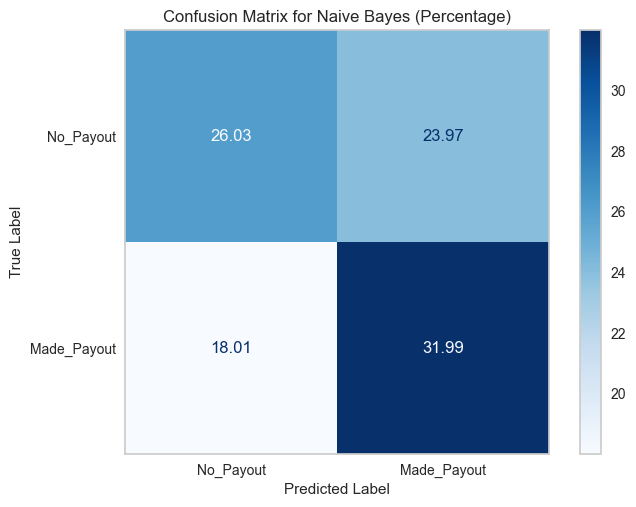

In [37]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_all, y_pred_all)

# Calculate percentages for each cell in the confusion matrix
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum() * 100

# Display the confusion matrix
class_labels = ['No_Payout', 'Made_Payout']
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_percentage, display_labels=class_labels)
disp.plot(cmap="Blues", values_format=".2f")  # Show numbers with 2 decimal places

# Customize plot labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix for Naive Bayes (Percentage)")

plt.grid(False)
plt.show()

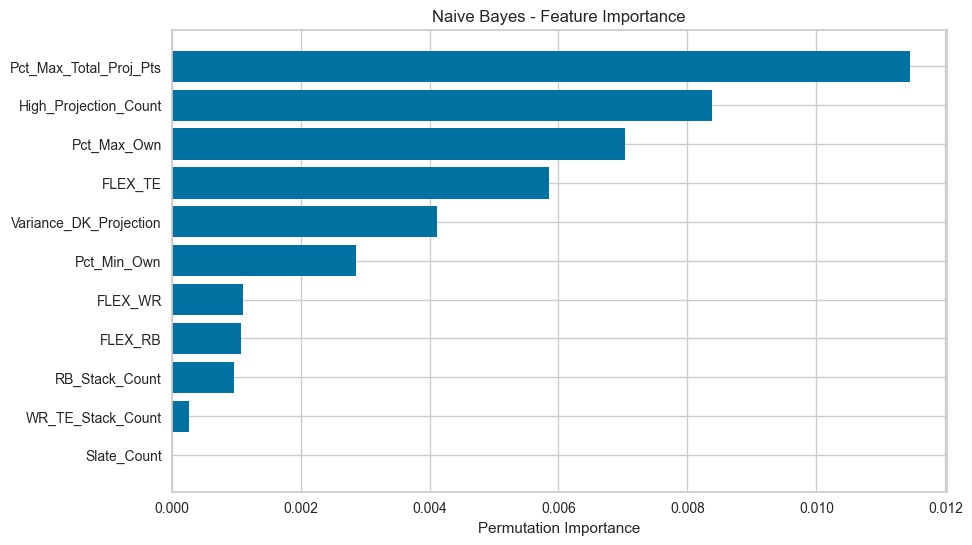

In [38]:
X_selected_scaled_df = pd.DataFrame(X_selected_scaled, columns=selected_feature_names)

# Calculate permutation importance
perm_importance = permutation_importance(nb_model, X_selected_scaled_df, y, n_repeats=10, random_state=42)

# Sort the feature importances
sorted_idx = perm_importance.importances_mean.argsort()

# Plot the permutation importance with correct column names
plt.figure(figsize=(10, 6))
plt.barh(X_selected_scaled_df.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Naive Bayes - Feature Importance")
plt.show()

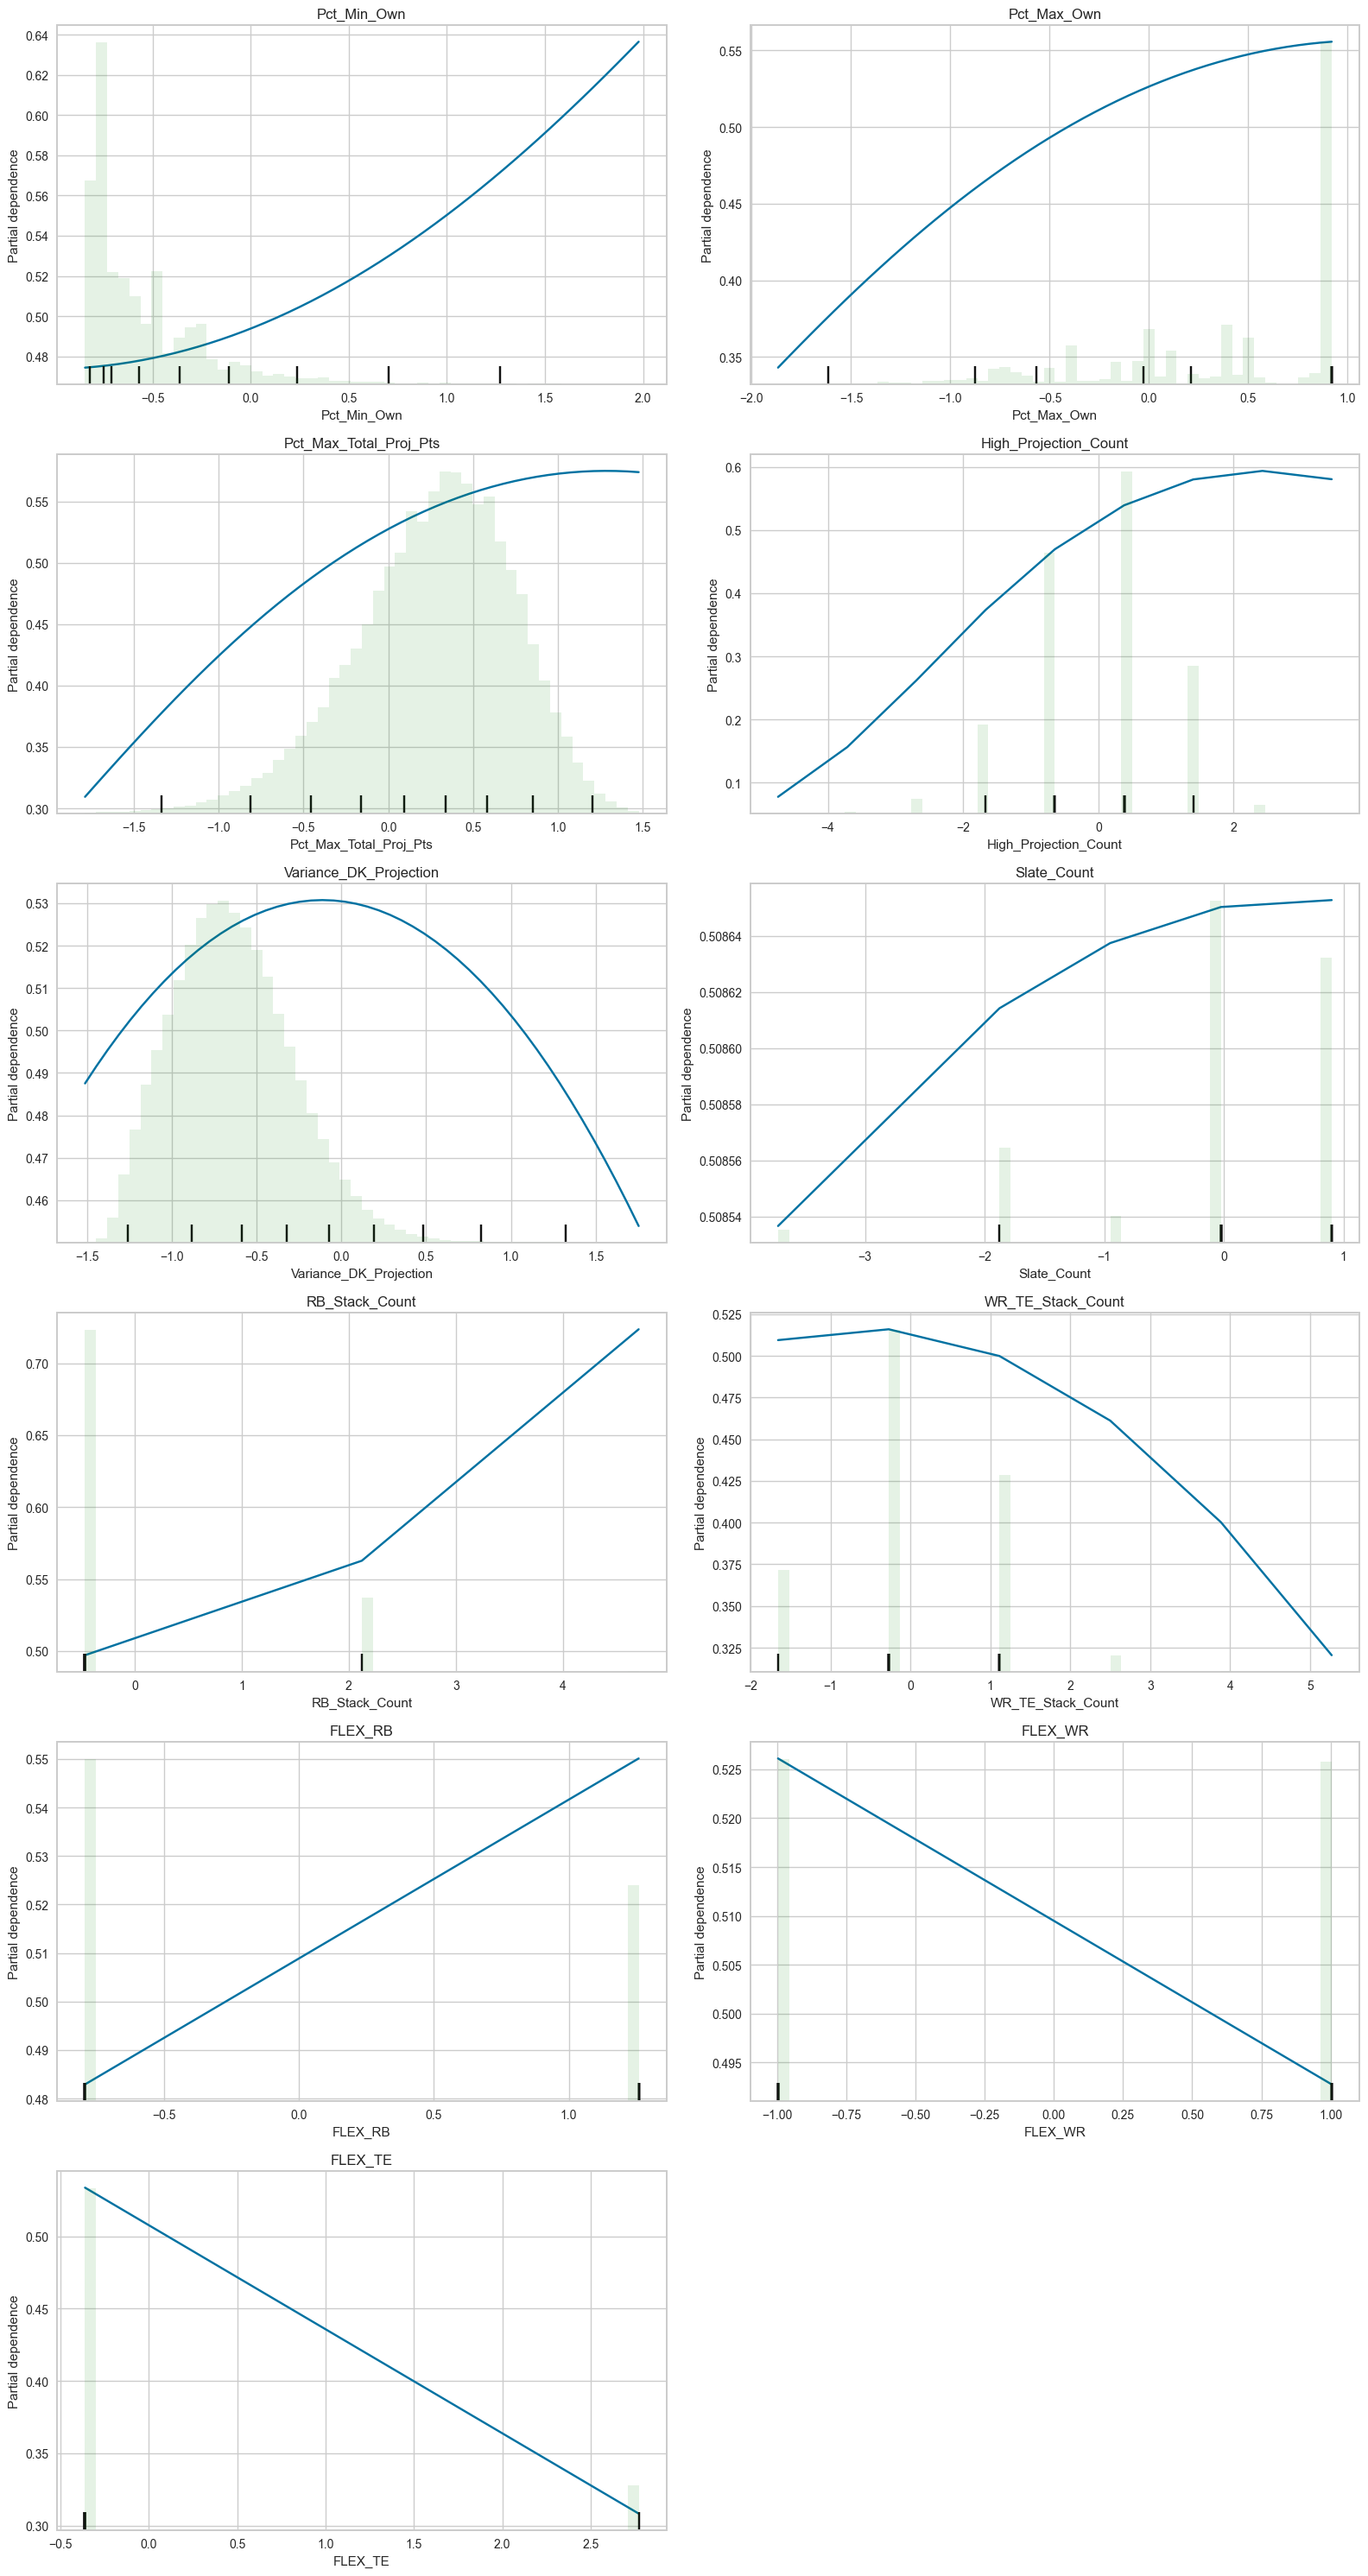

In [39]:
# List of features from the selected dataset (excluding the target)
feature_names = X_selected_scaled_df.columns.tolist()

# Define the number of rows and columns for the subplot grid
n_features = len(feature_names)
n_cols = 2  # Number of columns in the grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate the number of rows needed

# Create a figure and axes for the subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()  # Flatten to make it easier to iterate over

# Keep track of the valid axes to display (to remove empty plots later)
valid_axes = []

# Loop through each feature and plot the PDP along with the histogram
for i, feature in enumerate(feature_names):
    # Check if the feature is boolean before plotting
    if X_selected_scaled_df[feature].dtype == 'bool':
        print(f"Skipping boolean feature: {feature}")
        continue  # Skip to the next feature if it is boolean
    
    ax = axes[i]
    valid_axes.append(ax)  # Add valid axis for plotting
    
    # Plot the partial dependence plot
    pdp_display = PartialDependenceDisplay.from_estimator(
        nb_model,              # The trained model
        X_selected_scaled_df,  # Selected, scaled dataset
        features=[i],          # The index of the feature to plot
        grid_resolution=50,    # Number of points in grid for PDP
        ax=ax                  # Axis for the plot
    )
    
    # Plot the histogram of the feature's distribution in the background
    ax_hist = ax.twinx()  # Create a twin axis to overlay the histogram
    
    # Plot the histogram with the scaled numeric data
    ax_hist.hist(X_selected_scaled_df.iloc[:, i], bins=50, color='green', alpha=0.1)
    ax_hist.set_yticks([])  # Hide y-axis for the histogram
    
    # Set the title for each plot
    ax.set_title(feature)

# Remove any unused subplots
for ax in axes:
    if ax not in valid_axes:
        fig.delaxes(ax)  # Delete the axes that were not used

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

If the goal is to maximize the probability a lineup reaches payout, looking at the top three most important features above for simplicity, a lineup should:

1) Maximize its total projected points
2) Maximize the number of players in a lineup projected to score high (roughly above 14 points in this case)
3) Include a player with the projected highest ownership (also known as "playing the chalk")

## Evaluation of how model performs in contests ##

The section below goes through each slate and predicts the chances each lineup played reaches payout. Then it takes the top 150 lineups with the best chances and checks how well those lineups actually perform. It is important to note that these evaluations are being done on the balanced dataset and not the full contests. In the balanced dataset, an average lineup has a 50% chance of reaching payout.

In [40]:
# Predict probabilities for 'Made_Payout' on the selected, scaled test set
y_pred_proba = nb_model.predict_proba(X_selected_scaled_df)[:, 1]  # Probability of 'Made_Payout'

# Extract 'Slate_Info' and 'ROI' from the original balanced_df, matching indices with the test set
X_test_with_info = balanced_df.loc[X_selected_scaled_df.index, ['Slate_Info', 'ROI', 'Made_Payout']]

# Add the predicted probabilities to the test set info DataFrame
X_test_with_info = X_test_with_info.copy()  # To avoid warnings about chained assignments
X_test_with_info['Made_Payout_Probability'] = y_pred_proba

# Now combine the selected features back into the final DataFrame
X_test_with_features = X_selected_scaled_df.copy()  # Use the selected features for clarity
final_df = pd.concat([X_test_with_features.reset_index(drop=True), X_test_with_info.reset_index(drop=True)], axis=1)

# Display the resulting DataFrame
final_df.head()

,Pct_Min_Own,Pct_Max_Own,Pct_Max_Total_Proj_Pts,High_Projection_Count,Variance_DK_Projection,Slate_Count,RB_Stack_Count,WR_TE_Stack_Count,FLEX_RB,FLEX_WR,FLEX_TE,Slate_Info,ROI,Made_Payout,Made_Payout_Probability
0,0.433823,0.002731,0.532248,0.379956,0.635156,-0.024878,2.121502,-1.656139,1.259281,-0.996255,-0.360736,2024-09-08,-1.0,0,0.790720
1,0.182805,-0.876805,0.245998,1.403307,-0.629163,-0.024878,-0.464898,1.114430,-0.794104,1.003759,-0.360736,2024-09-08,-1.0,0,0.552448
2,-0.277394,-0.876805,-0.444369,-0.643395,-1.298518,-0.024878,2.121502,-0.270855,-0.794104,-0.996255,2.772107,2024-09-08,-1.0,0,0.202195
3,-0.277394,0.919431,-0.511722,-0.643395,-1.151851,-0.024878,2.121502,-0.270855,-0.794104,1.003759,-0.360736,2024-09-08,-1.0,0,0.521725
4,0.182805,0.919431,0.616439,1.403307,-0.823079,-0.024878,-0.464898,-0.270855,1.259281,-0.996255,-0.360736,2024-09-08,-1.0,0,0.790979


In [41]:
# Top 150 Made_Payout probabilities for each slate results
# This is just for reference. this is evaluated on the balanced datasets, which will not match actual payout percentages and projected ROI

# Group by Slate_Info and select the top 100 Made_Payout probabilities for each Slate_Info
top_150_by_slate = final_df.groupby('Slate_Info', group_keys=False).apply(
    lambda x: x.nlargest(150, 'Made_Payout_Probability')
)

# Calculate the actual Made_Payout percentage for each Slate_Info
# Made_Payout is considered true if 'ROI' > 0 (based on your earlier question)
top_150_grouped = top_150_by_slate.groupby('Slate_Info').agg(
    Actual_Made_Payout_Percentage=('ROI', lambda x: (x > 0).mean() * 100),  # Percentage of ROI > 0
    Mean_ROI=('ROI', 'mean')  # Mean ROI for the top 100
).reset_index()

# Display the resulting DataFrame
top_150_grouped

,Slate_Info,Actual_Made_Payout_Percentage,Mean_ROI
0,2024-09-08,80.000000,1.386667
1,2024-09-15,49.333333,0.186667
2,2024-09-22,41.333333,-0.150000
3,2024-09-29,38.000000,-0.140000
4,2024-10-06,37.333333,-0.232467
5,2024-10-13,74.666667,0.640667
6,2024-10-20,60.666667,0.140600
7,2024-10-27,71.333333,0.641600
8,2024-11-03,84.000000,3.493333
9,2024-11-10,69.333333,1.547733


In [42]:
# Confusion matrix components
cm = confusion_matrix(y_true_all, y_pred_all)
TP = cm[1, 1]
FP = cm[0, 1]
TN = cm[0, 0]
FN = cm[1, 0]

# Calculate precision and recall
precision = TP / (TP + FP)
recall = TP / (TP + FN)

# Actual and model positive rates
actual_positive_rate = average_slate_made_payout  # ~25% true Made_Payout rate in real slate
model_positive_rate = 0.5    # 50% Made_Payout rate in the model

# Adjusted Expected Made_Payout Percentage
expected_made_payout_percentage = (actual_positive_rate / model_positive_rate) * precision * 100

print(f"Slate Made_Payout Percentage: {average_slate_made_payout*100:.2f}%")
print(f"Adjusted Expected Made_Payout Percentage: {expected_made_payout_percentage:.2f}%")

Slate Made_Payout Percentage: 25.08%
Adjusted Expected Made_Payout Percentage: 28.67%


## Conclusion

This module set out to maximize chances lineups reach payout. In a typical contest, roughly the top 25% lineups reach payout. With the help of this notebook, lineups can be submitted to increase those chances to above 28%. With that said, this is not an ideal strategy. The payout structure of contests are typically extremely top-heavy. There are better options to use in practice. This notebook just set out for a low-risk goal of reaching payout as more of a proof of concept.